In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

In [2]:
df = pd.read_csv("C:\\Users\\sobha\\OneDrive\\Desktop\\CODING\\PE1\\updated_file.csv")
df.describe()

,subject,Email Text,Email Type
count,2831,2893,2893
unique,2612,2859,2
top,sociolinguistics,this is not spam ; you are receiving this mess...,Safe Email
freq,8,5,2412


In [3]:
df.head(10)

,subject,Email Text,Email Type
0,job posting - apple-iss research center,content - length : 3386 apple-iss research cen...,Safe Email
1,NaN,"lang classification grimes , joseph e . and ba...",Safe Email
2,query : letter frequencies for text identifica...,i am posting this inquiry for sergei atamas ( ...,Safe Email
3,risk,a colleague and i are researching the differin...,Safe Email
4,request book information,earlier this morning i was on the phone with a...,Safe Email
5,call for abstracts : optimality in syntactic t...,content - length : 4437 call for papers is the...,Safe Email
6,m . a . in scandinavian linguistics,m . a . in scandinavian linguistics at the uni...,Safe Email
7,call for papers : linguistics session of the m...,call for papers linguistics session - - midwes...,Safe Email
8,foreign language in commercials,content - length : 1937 greetings ! i ' m wond...,Safe Email
9,fulbright announcement : please post / dissemi...,fulbright announcement : please post / dissemi...,Safe Email


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2893 entries, 0 to 2892
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   subject     2831 non-null   object
 1   Email Text  2893 non-null   object
 2   Email Type  2893 non-null   object
dtypes: object(3)
memory usage: 67.9+ KB
None


In [ ]:
df = df.dropna(subset=['Email Text'])

In [6]:
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS as stop_words

def clean_text(text):
    text = re.sub(r'\W', ' ', text)  
    text = text.lower()  
    text = text.split()  
    text = [word for word in text if word not in stop_words]  
    return ' '.join(text)

In [7]:
cleaned_emails = df['Email Text'].apply(clean_text).tolist()

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(cleaned_emails)

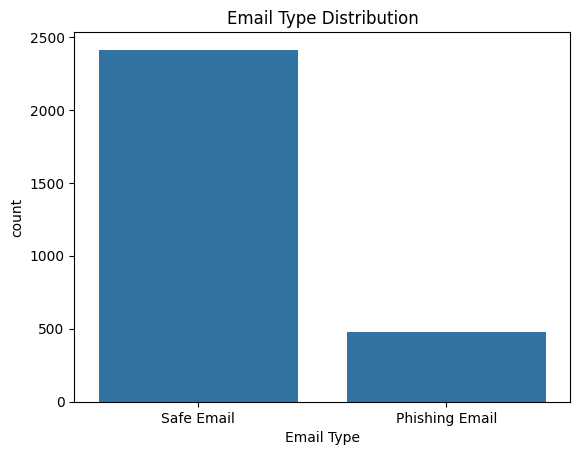

In [9]:
sns.countplot(x='Email Type', data=df)
plt.title('Email Type Distribution')
plt.show()

In [10]:
y = df['Email Type'].map({'Safe Email': 0, 'Phishing Email': 1})

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from scipy.stats import uniform

param_dist = {
    'C': uniform(loc=0.01, scale=10), 
    'penalty': ['l1', 'l2'],            
    'solver': ['liblinear', 'saga']     
}
logistic_model = LogisticRegression(max_iter=1000)
random_search = RandomizedSearchCV(logistic_model, param_distributions=param_dist, n_iter=10, cv=5, verbose=2, n_jobs=-1, random_state=42)

random_search.fit(X_train, y_train)
print("The best hyperparameters are:")
print(random_search.best_params_)

print("\nBest result:")
print("Accuracy:", random_search.best_score_)


Fitting 5 folds for each of 10 candidates, totalling 50 fits
The best hyperparameters are:
{'C': 8.334426408004218, 'penalty': 'l2', 'solver': 'saga'}

Best result:
Accuracy: 0.9866025263433471


In [13]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score


best_model = random_search.best_estimator_
y_pred_best = best_model.predict(X_test)

print("Model Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))

print("\nModel Classification Report:")
print(classification_report(y_test, y_pred_best))

print("\nModel Accuracy Score:")
print(accuracy_score(y_test, y_pred_best))

Model Confusion Matrix:
[[464   0]
 [  5 110]]

Model Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       464
           1       1.00      0.96      0.98       115

    accuracy                           0.99       579
   macro avg       0.99      0.98      0.99       579
weighted avg       0.99      0.99      0.99       579


Model Accuracy Score:
0.9913644214162349
